In [1]:
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, LinearRegression
import xgboost as xgb
import matplotlib.pyplot as plt

import openbb as obb
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats import norm, skewnorm, t

In [2]:
import yfinance as yf

tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
data = yf.download(tickers, start='2020-01-01', end='2025-01-01')["Close"]
returns = data.pct_change().dropna()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  4 of 4 completed


In [3]:
returns

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2020-01-03,-0.009722,-0.012139,-0.005231,-0.012452
2020-01-06,0.007968,0.014886,0.026654,0.002585
2020-01-07,-0.004703,0.002092,-0.001932,-0.009118
2020-01-08,0.016086,-0.007809,0.007118,0.015929
2020-01-09,0.021241,0.004799,0.010498,0.012493
...,...,...,...,...
2024-12-24,0.011478,0.017729,0.007604,0.009374
2024-12-26,0.003176,-0.008732,-0.002601,-0.002777
2024-12-27,-0.013242,-0.014534,-0.014519,-0.017302


In [4]:
returns_monthly = data.resample("BMS").first()

In [5]:
returns_monthly = returns_monthly.pct_change().dropna()

In [6]:
returns_monthly.head()

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2020-02-03,0.027668,0.055948,0.083234,0.085668
2020-03-02,-0.029615,-0.025072,-0.064940,-0.006412
2020-04-01,-0.193768,-0.023670,-0.205018,-0.119683
2020-05-01,0.199908,0.198323,0.195282,0.147656
2020-06-01,0.116412,0.080926,0.089234,0.050233


In [7]:
covariance = {}
for i in returns_monthly.index:
    rtd_index = returns.index
    mask = (rtd_index.month == i.month) & (rtd_index.year == i.year)
    covariance[i] = returns[mask].cov()

In [8]:
portfolio_returns = {}
portfolio_volatility = {}
portfolio_weights = {}
for date in covariance.keys():
    cov = covariance[date]
    for k in range(10000):
        weights = np.random.random(4)
        weights = weights/np.sum(weights)
        returnss = np.dot(weights, returns_monthly.loc[date])
        volatility = np.sqrt(np.dot(weights.T,np.dot(cov, weights)))
        portfolio_returns.setdefault(date,[]).append(returnss)
        portfolio_volatility.setdefault(date,[]).append(volatility)
        portfolio_weights.setdefault(date,[]).append(weights)




In [17]:
sharpe_ratio = {}
max_sharpe = {}
vols = {}
min_vol = {}
for date in covariance.keys():
    for i, (ret, vol) in enumerate(zip(portfolio_returns[date], portfolio_volatility[date])):
        sharpe_ratio.setdefault(date, []).append(ret / vol)
        vols.setdefault(date, []).append(vol)
    max_sharpe[date] = np.argmax(sharpe_ratio[date])
    min_vol[date] = np.argmin(vols[date])

print(max_sharpe)

{Timestamp('2020-02-03 00:00:00'): np.int64(6369), Timestamp('2020-03-02 00:00:00'): np.int64(8776), Timestamp('2020-04-01 00:00:00'): np.int64(6899), Timestamp('2020-05-01 00:00:00'): np.int64(3155), Timestamp('2020-06-01 00:00:00'): np.int64(191), Timestamp('2020-07-01 00:00:00'): np.int64(173), Timestamp('2020-08-03 00:00:00'): np.int64(2958), Timestamp('2020-09-01 00:00:00'): np.int64(1497), Timestamp('2020-10-01 00:00:00'): np.int64(4273), Timestamp('2020-11-02 00:00:00'): np.int64(330), Timestamp('2020-12-01 00:00:00'): np.int64(1087), Timestamp('2021-01-01 00:00:00'): np.int64(367), Timestamp('2021-02-01 00:00:00'): np.int64(9649), Timestamp('2021-03-01 00:00:00'): np.int64(3085), Timestamp('2021-04-01 00:00:00'): np.int64(2959), Timestamp('2021-05-03 00:00:00'): np.int64(1859), Timestamp('2021-06-01 00:00:00'): np.int64(4579), Timestamp('2021-07-01 00:00:00'): np.int64(957), Timestamp('2021-08-02 00:00:00'): np.int64(7306), Timestamp('2021-09-01 00:00:00'): np.int64(7498), Time

In [38]:
apple = []
microsoft = []
google = []
amazon = []
apple2 = []
microsoft2 = []
google2 = []
amazon2 = []
for date in covariance.keys():
    apple.append(portfolio_weights[date][max_sharpe[date]][0])
    microsoft.append(portfolio_weights[date][max_sharpe[date]][1])
    google.append(portfolio_weights[date][max_sharpe[date]][2])
    amazon.append(portfolio_weights[date][max_sharpe[date]][3])
    apple2.append(portfolio_weights[date][min_vol[date]][0])
    microsoft2.append(portfolio_weights[date][min_vol[date]][1])
    google2.append(portfolio_weights[date][min_vol[date]][2])
    amazon2.append(portfolio_weights[date][min_vol[date]][3])
print(np.mean(apple2))
print(np.mean(microsoft2))
print(np.mean(google2))
print(np.mean(amazon2))
print(np.mean(apple) + np.mean(microsoft) + np.mean(google)+ np.mean(amazon))
avg_weights = [np.mean(apple), np.mean(microsoft),np.mean(google), np.mean(amazon) ]
avg_weights2 = [np.mean(apple2), np.mean(microsoft2),np.mean(google2), np.mean(amazon2) ]

0.3334035908366119
0.14848968057592313
0.179621686837656
0.3384850417498088
1.0


In [58]:

cumulative_returns = (1 + returns_monthly).cumprod()

In [59]:
cumulative_returns

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2020-02-03,1.027668,1.055948,1.083234,1.085668
2020-03-02,0.997234,1.029473,1.012889,1.078707
2020-04-01,0.804001,1.005105,0.805228,0.949604
2020-05-01,0.964728,1.204440,0.962475,1.089819
2020-06-01,1.077034,1.301911,1.048361,1.144564
2020-07-01,1.218452,1.516694,1.053570,1.281476
2020-08-03,1.458187,1.639554,1.083351,1.355598
2020-09-01,1.799310,1.843573,1.209253,1.426210
2020-10-01,1.566116,1.697178,1.087106,1.333271


In [67]:
cash = 10


asset_total_returns = cumulative_returns.iloc[-1] - 1  


average_returns  = np.sum(avg_weights  * asset_total_returns)
average_returns2 = np.sum(avg_weights2 * asset_total_returns)


final_value1 = cash * (1 + average_returns)
final_value2 = cash * (1 + average_returns2)

print(f"Strategy 1 (Max Sharpe):     Final Value = ${final_value1:.2f} | Return = {average_returns:.2%}")
print(f"Strategy 2 (Min Volatility): Final Value = ${final_value2:.2f} | Return = {average_returns2:.2%}")
print("Individual asset returns:",  asset_total_returns*100)

Strategy 1 (Max Sharpe):     Final Value = $27.63 | Return = 176.29%
Strategy 2 (Min Volatility): Final Value = $28.28 | Return = 182.78%
Individual asset returns: Ticker
AAPL     229.125112
AMZN     122.032563
GOOGL    151.212374
MSFT     180.529826
Name: 2024-12-02 00:00:00, dtype: float64


In [57]:
dates = sorted(covariance.keys())

strategy_returns = []
strategy_returns2 = []

for i in range(len(dates) - 1):
    current_date = dates[i]
    next_date = dates[i + 1]

    weights = portfolio_weights[current_date][min_vol[current_date]]
    weights2 = portfolio_weights[current_date][max_sharpe[current_date]]

    returns_next = returns_monthly.loc[next_date] 

    port_return = np.dot(weights, returns_next)
    port_return2 = np.dot(weights2, returns_next)
    strategy_returns.append(port_return)
    strategy_returns2.append(port_return2)

strategy_returns = pd.Series(strategy_returns, index=dates[1:])
strategy_returns2 = pd.Series(strategy_returns2, index=dates[1:])

cumulative_returns = (1 + strategy_returns).cumprod()

total_return = cumulative_returns.iloc[-1] - 1

cumulative_returns2 = (1 + strategy_returns2).cumprod()

total_return2 = cumulative_returns2.iloc[-1] - 1

print(f"Total return from strategy of minimum volatility: {total_return:.2%}")
print(f"Total return from strategy of max sharpe: {total_return2:.2%}")

Total return from strategy of minimum volatility: 228.80%
Total return from strategy of max sharpe: 177.59%


In [68]:
from arch import arch_model

In [77]:
basic_gm = arch_model(returns["AAPL"], p = 1, q= 1, mean="constant", vol="GARCH", dist="normal")

In [81]:
gm_result = basic_gm.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 1.4534495353022437e+19
Iteration:      2,   Func. Count:     18,   Neg. LLF: 88809.44316005637
Iteration:      3,   Func. Count:     29,   Neg. LLF: 9.910971269557547e+16
Iteration:      4,   Func. Count:     41,   Neg. LLF: 3.347829988589558e+20
Iteration:      5,   Func. Count:     56,   Neg. LLF: 72185023268704.45
Optimization terminated successfully    (Exit mode 0)
            Current function value: -3278.2804095471893
            Iterations: 8
            Function evaluations: 63
            Gradient evaluations: 5


/Users/aimaraguadoberasaluce/Desktop/Financial/Machine-Learning-in-Finance/openbb_env/lib/python3.10/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003979. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


In [82]:
print(gm_result.params, gm_result.summary)

mu          0.001664
omega       0.000008
alpha[1]    0.100000
beta[1]     0.880000
Name: params, dtype: float64 <bound method ARCHModelResult.summary of                      Constant Mean - GARCH Model Results                      
Dep. Variable:                   AAPL   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                3278.28
Distribution:                  Normal   AIC:                          -6548.56
Method:            Maximum Likelihood   BIC:                          -6528.01
                                        No. Observations:                 1257
Date:                Sat, Jul 12 2025   Df Residuals:                     1256
Time:                        12:17:55   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|    

In [80]:
gm_result.tvalues

mu               3.103325
omega       223499.340166
alpha[1]         3.295448
beta[1]         34.133100
Name: tvalues, dtype: float64

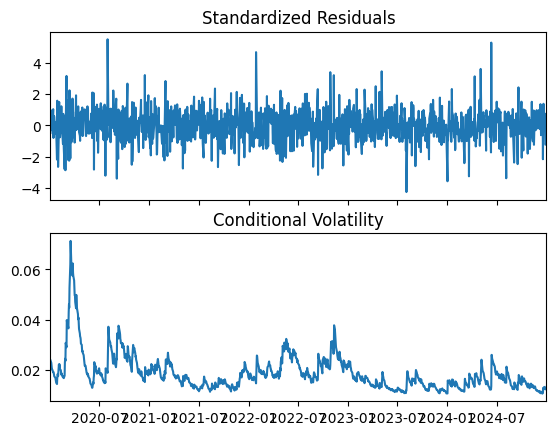

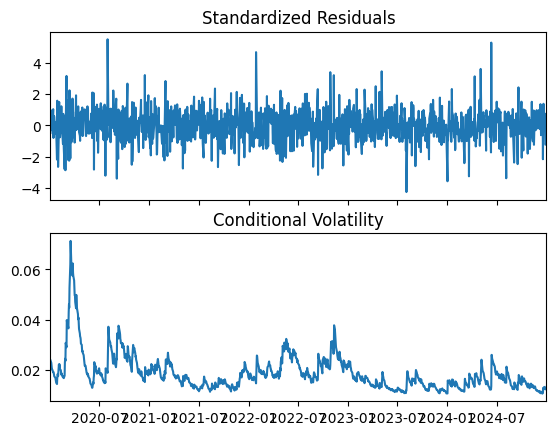

In [83]:
gm_result.plot()

In [84]:
gm_std_resid = gm_result.resid/gm_result.conditional_volatility

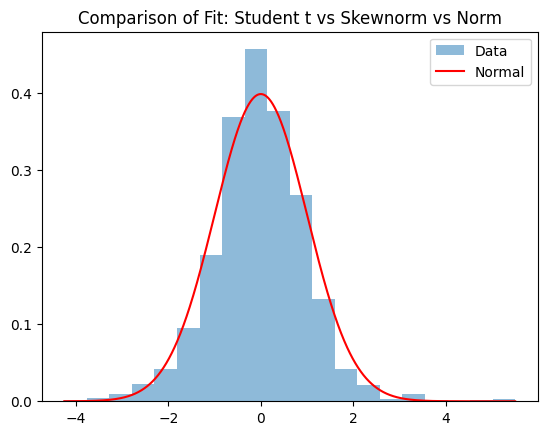

In [93]:

plt.hist(gm_std_resid, bins = 20,density=True, alpha=0.5, label="Data")
x = np.linspace(gm_std_resid.min(), gm_std_resid.max(), 1000)
pdf_norm = norm.pdf(x, loc=0, scale=1)
plt.plot(x, pdf_norm, 'r-', label="Normal")
plt.legend()
plt.title("Comparison of Fit: Student t vs Skewnorm vs Norm")
plt.show()

In [94]:
from scipy.stats import entropy
import numpy as np

hist, bin_edges = np.histogram(gm_std_resid, bins=50, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

pdf_norm = norm.pdf(bin_centers, loc=0, scale=1)

epsilon = 1e-10
kl_divergence = entropy(hist + epsilon, pdf_norm + epsilon)
print(f"KL divergence (Normal fit): {kl_divergence}")

KL divergence (Normal fit): 0.05019086372958166
